## inference/ simulation notebook

In [18]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

In [19]:
# loading the model and dataset

model = joblib.load("../models/best_model.pkl")

data = pd.read_csv(
    "../data/processed/master_dataset_with_clusters.csv"
)

print(data.shape)
data.head()

(11869, 13)


,Year,Race,Driver,Team,LapNumber,Compound,TyreLife,Stint,Position,TrackStatus,LapTimeSeconds,DrivingStyleCluster,DrivingStyle
0,2024.0,Spain,VER,Red Bull Racing,1.0,SOFT,4.0,1.0,2.0,1.0,83.186,3.0,Fast & Efficient Driver
1,2024.0,Spain,VER,Red Bull Racing,2.0,SOFT,5.0,1.0,2.0,1.0,79.871,3.0,Fast & Efficient Driver
2,2024.0,Spain,VER,Red Bull Racing,3.0,SOFT,6.0,1.0,1.0,1.0,79.364,3.0,Fast & Efficient Driver
3,2024.0,Spain,VER,Red Bull Racing,4.0,SOFT,7.0,1.0,1.0,1.0,80.766,3.0,Fast & Efficient Driver
4,2024.0,Spain,VER,Red Bull Racing,5.0,SOFT,8.0,1.0,1.0,1.0,80.827,3.0,Fast & Efficient Driver


In [20]:
print(data.columns.tolist())

['Year', 'Race', 'Driver', 'Team', 'LapNumber', 'Compound', 'TyreLife', 'Stint', 'Position', 'TrackStatus', 'LapTimeSeconds', 'DrivingStyleCluster', 'DrivingStyle']


In [21]:
print(data.isnull().sum())

data = data.dropna()

print("\nShape after removing missing values:")
print(data.shape)

Year                   0
Race                   0
Driver                 0
Team                   0
LapNumber              0
Compound               0
TyreLife               0
Stint                  0
Position               0
TrackStatus            0
LapTimeSeconds         0
DrivingStyleCluster    0
DrivingStyle           0
dtype: int64

Shape after removing missing values:
(11869, 13)


In [22]:
# encoding categorical columns

categorical_cols = [
    "Driver",
    "Team",
    "Compound",
    "Race"
]

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    data[col] = le.fit_transform(data[col])

    encoders[col] = le

In [23]:
# preparing training features

feature_columns = [
    "Driver",
    "Team",
    "Compound",
    "TyreLife",
    "Stint",
    "Position",
    "TrackStatus",
    "DrivingStyleCluster"
]

target_column = "LapTimeSeconds"

X = data[feature_columns]

y = data[target_column]

print(X.shape)

(11869, 8)


In [24]:
driver_encoder = encoders["Driver"]

print(driver_encoder.classes_)

['ALB' 'ALO' 'BOT' 'COL' 'DEV' 'GAS' 'HAM' 'HUL' 'LAT' 'LAW' 'LEC' 'MAG'
 'MSC' 'NOR' 'OCO' 'PER' 'PIA' 'RIC' 'RUS' 'SAI' 'SAR' 'STR' 'TSU' 'VER'
 'VET' 'ZHO']


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

def predict_driver(driver_code,
                   compound="SOFT",
                   start_tyre_life=1,
                   max_laps=30,
                   min_stint_laps=5):

    # ---------------------------------------
    # Convert driver name to encoded value
    # ---------------------------------------

    driver_encoder = encoders["Driver"]

    if driver_code not in driver_encoder.classes_:
        print(f"{driver_code} not found.")
        return

    encoded_driver = driver_encoder.transform([driver_code])[0]

    # ---------------------------------------
    # Find latest sample row
    # ---------------------------------------

    driver_rows = data[data["Driver"] == encoded_driver]

    if len(driver_rows) == 0:
        print("Driver not found!")
        return

    row = driver_rows.iloc[-1].copy()

    compound_encoder = encoders["Compound"]
    encoded_compound = compound_encoder.transform([compound])[0]

    predictions = []
    tyre_lives = []

    for tyre_age in range(start_tyre_life, max_laps + 1):

        row["TyreLife"] = tyre_age
        row["LapNumber"] = tyre_age
        row["Compound"] = encoded_compound
        row["Stint"] = 1

        pred = model.predict(
            pd.DataFrame([row[feature_columns]])
        )[0]

        tyre_lives.append(tyre_age)
        predictions.append(pred)

    future_df = pd.DataFrame({
        "TyreLife": tyre_lives,
        "PredictedLapTime": predictions
    })

    # --------------------------------------------------------
    # First few laps are ignored because tyre warm-up and
    # out-lap effects create artificially slow lap times that
    # do not represent true degradation onset.
    # --------------------------------------------------------

    lap_diff = future_df["PredictedLapTime"].diff()

    threshold = 0.5

    valid_rows = future_df["TyreLife"] >= min_stint_laps

    candidate_rows = future_df[
        valid_rows &
        (lap_diff > threshold)
    ]

    if len(candidate_rows) > 0:
        pit_lap = candidate_rows.iloc[0]["TyreLife"]
    else:
        pit_lap = future_df["TyreLife"].iloc[-1]

    # ---------------------------------------
    # Plot
    # ---------------------------------------

    plt.figure(figsize=(10,5))

    plt.plot(
        future_df["TyreLife"],
        future_df["PredictedLapTime"],
        marker="o",
        label="Predicted Lap Time"
    )

    plt.axvspan(
        pit_lap-1,
        pit_lap+1,
        color="red",
        alpha=0.25,
        label="Recommended Pit Window"
    )

    plt.axvline(
        pit_lap,
        color="red",
        linestyle="--"
    )

    plt.xlabel("Tyre Life (laps)")
    plt.ylabel("Predicted Lap Time (seconds)")
    plt.title(f"{driver_code} Tyre Degradation Prediction")

    plt.grid(True)
    plt.legend()

    plt.show()

    print("="*45)
    print(f"Driver        : {driver_code}")
    print(f"Compound      : {compound}")
    print(f"Pit Lap       : {pit_lap}")
    print(f"Minimum Stint : {min_stint_laps}")
    print("="*45)

    display(future_df.head())

    return future_df

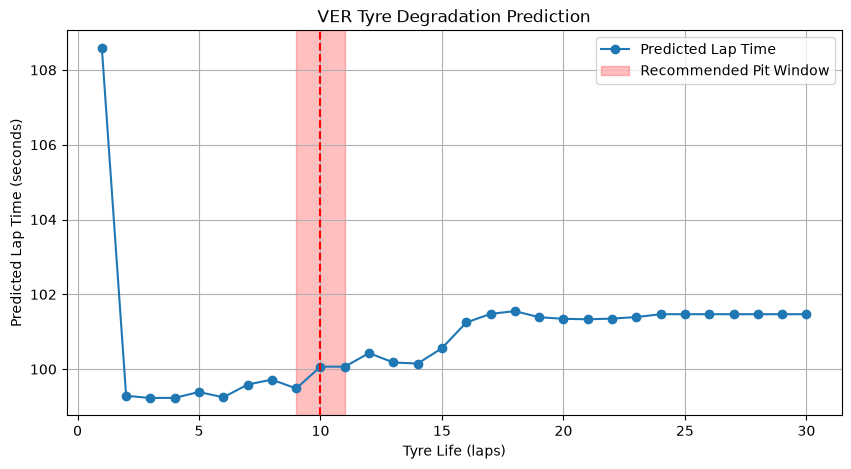

Driver        : VER
Compound      : SOFT
Pit Lap       : 10.0
Minimum Stint : 5


,TyreLife,PredictedLapTime
0,1,108.586583
1,2,99.287659
2,3,99.228410
3,4,99.232222
4,5,99.389213


,TyreLife,PredictedLapTime
0,1,108.586583
1,2,99.287659
2,3,99.228410
3,4,99.232222
4,5,99.389213
5,6,99.246265
6,7,99.588163
7,8,99.719320
8,9,99.482848
9,10,100.066853


In [27]:
predict_driver("VER")

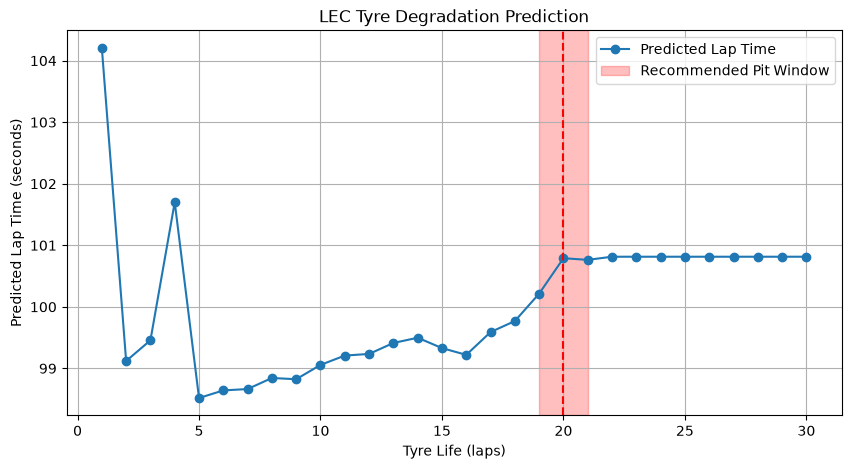

Driver        : LEC
Compound      : MEDIUM
Pit Lap       : 20.0
Minimum Stint : 5


,TyreLife,PredictedLapTime
0,1,104.205623
1,2,99.119237
2,3,99.456453
3,4,101.699250
4,5,98.518683


,TyreLife,PredictedLapTime
0,1,104.205623
1,2,99.119237
2,3,99.456453
3,4,101.699250
4,5,98.518683
5,6,98.641825
6,7,98.664110
7,8,98.843747
8,9,98.823730
9,10,99.056077


In [28]:
predict_driver("LEC", compound="MEDIUM")

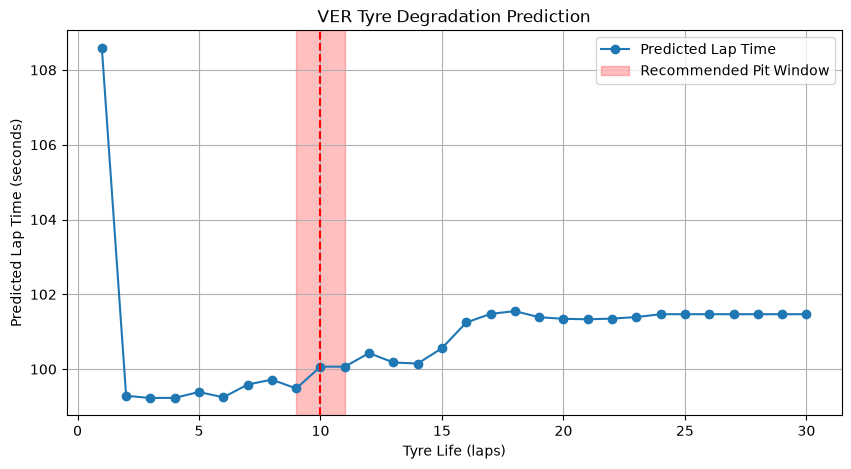

Driver        : VER
Compound      : SOFT
Pit Lap       : 10.0
Minimum Stint : 5


,TyreLife,PredictedLapTime
0,1,108.586583
1,2,99.287659
2,3,99.228410
3,4,99.232222
4,5,99.389213


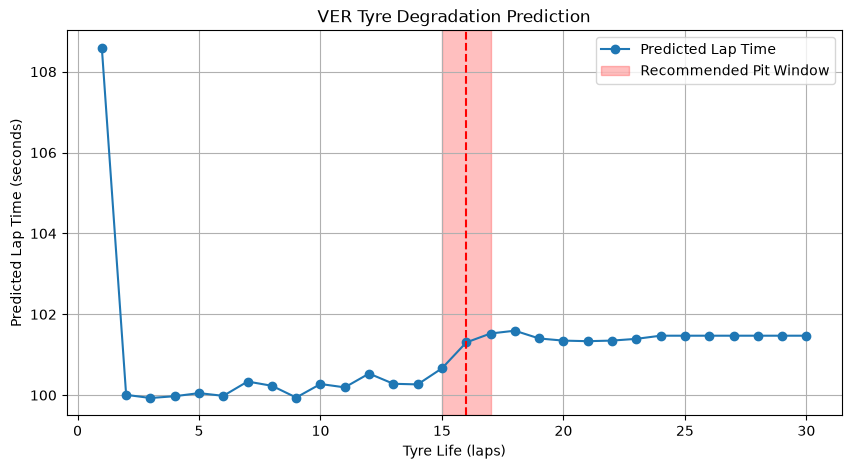

Driver        : VER
Compound      : MEDIUM
Pit Lap       : 16.0
Minimum Stint : 5


,TyreLife,PredictedLapTime
0,1,108.586263
1,2,100.007829
2,3,99.930003
3,4,99.973977
4,5,100.050570


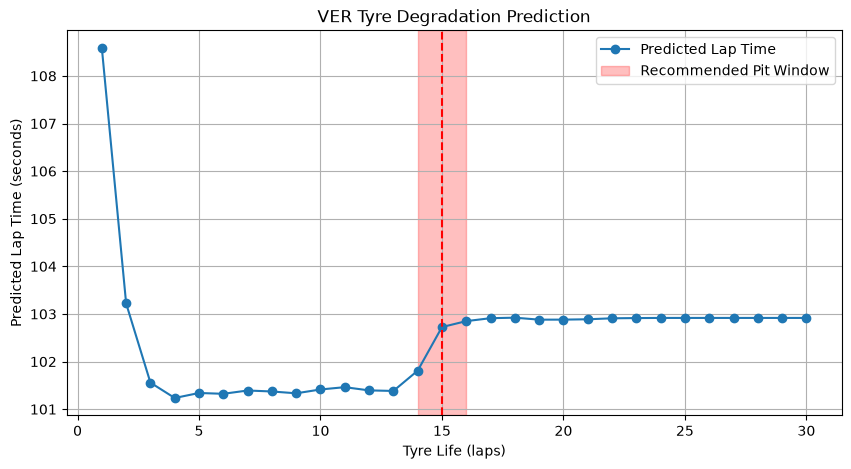

Driver        : VER
Compound      : HARD
Pit Lap       : 15.0
Minimum Stint : 5


,TyreLife,PredictedLapTime
0,1,108.586263
1,2,103.220737
2,3,101.557893
3,4,101.235247
4,5,101.340513


F1 STRATEGY RECOMMENDATION
  Compound  Recommended Pit Lap  Average Lap Time (s)  Fastest Lap (s)
0     SOFT                   10               100.886           99.228
1   MEDIUM                   16               101.093           99.930
2     HARD                   15               102.504          101.235


BEST STRATEGY
Driver              : VER
Best Compound       : SOFT
Recommended Pit Lap : 10
Average Lap Time    : 100.886 sec
Fastest Lap         : 99.228 sec


In [33]:
# =====================================================
# STRATEGY COMPARISON FOR ALL THREE COMPOUNDS
# =====================================================

import pandas as pd

driver = "VER"      # Change driver here

results = []

for compound in ["SOFT", "MEDIUM", "HARD"]:

    # Get prediction dataframe
    future_df = predict_driver(
        driver_code=driver,
        compound=compound
    )

    # Skip if driver not found
    if future_df is None:
        continue

    # -------------------------------------------------
    # Ignore first few laps (warm-up phase)
    # -------------------------------------------------
    analysis_df = future_df[future_df["TyreLife"] >= 5].copy()

    lap_diff = analysis_df["PredictedLapTime"].diff()

    threshold = 0.5

    if (lap_diff > threshold).any():

        pit_lap = int(
            analysis_df.loc[
                lap_diff > threshold,
                "TyreLife"
            ].iloc[0]
        )

    else:

        pit_lap = int(analysis_df["TyreLife"].iloc[-1])

    results.append({

        "Compound": compound,
        "Recommended Pit Lap": pit_lap,
        "Average Lap Time (s)": round(
            future_df["PredictedLapTime"].mean(),3
        ),
        "Fastest Lap (s)": round(
            future_df["PredictedLapTime"].min(),3
        )

    })

# =====================================================
# SHOW RESULTS
# =====================================================

strategy_df = pd.DataFrame(results)

print("="*60)
print("F1 STRATEGY RECOMMENDATION")
print("="*60)

print(strategy_df)

# =====================================================
# BEST STRATEGY
# =====================================================

best = strategy_df.sort_values(
    by=["Average Lap Time (s)",
        "Recommended Pit Lap"]
).iloc[0]

print("\n")
print("="*60)
print("BEST STRATEGY")
print("="*60)

print(f"Driver              : {driver}")
print(f"Best Compound       : {best['Compound']}")
print(f"Recommended Pit Lap : {best['Recommended Pit Lap']}")
print(f"Average Lap Time    : {best['Average Lap Time (s)']} sec")
print(f"Fastest Lap         : {best['Fastest Lap (s)']} sec")

print("="*60)

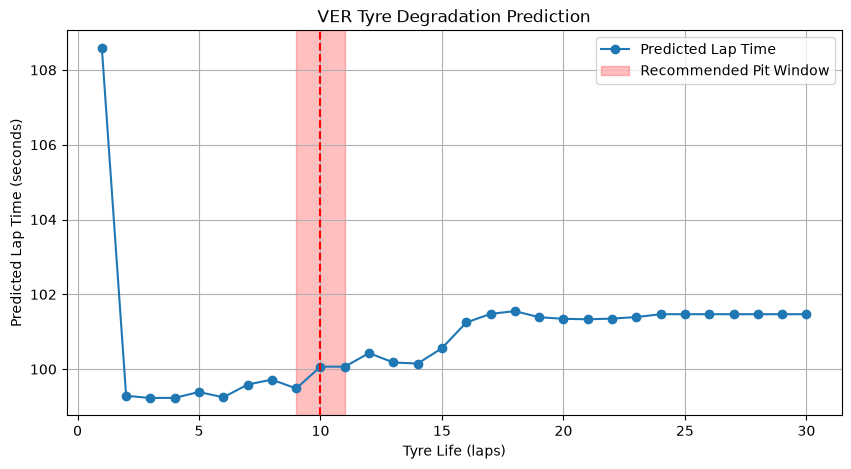

Driver        : VER
Compound      : SOFT
Pit Lap       : 10.0
Minimum Stint : 5


,TyreLife,PredictedLapTime
0,1,108.586583
1,2,99.287659
2,3,99.228410
3,4,99.232222
4,5,99.389213


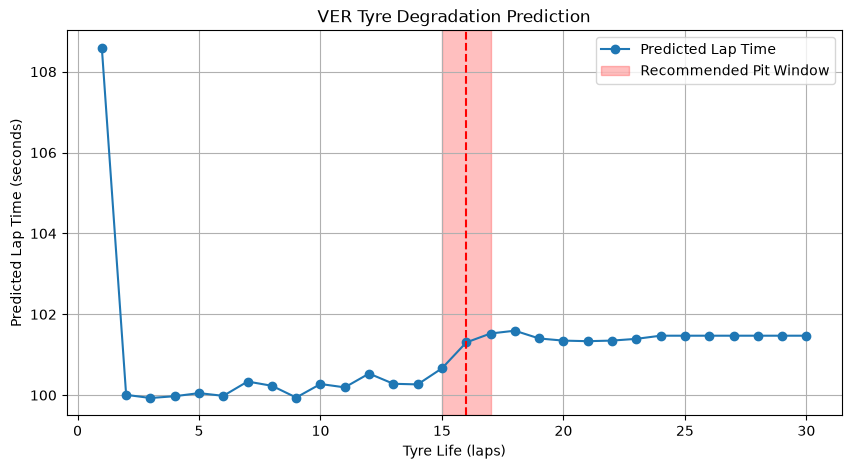

Driver        : VER
Compound      : MEDIUM
Pit Lap       : 16.0
Minimum Stint : 5


,TyreLife,PredictedLapTime
0,1,108.586263
1,2,100.007829
2,3,99.930003
3,4,99.973977
4,5,100.050570


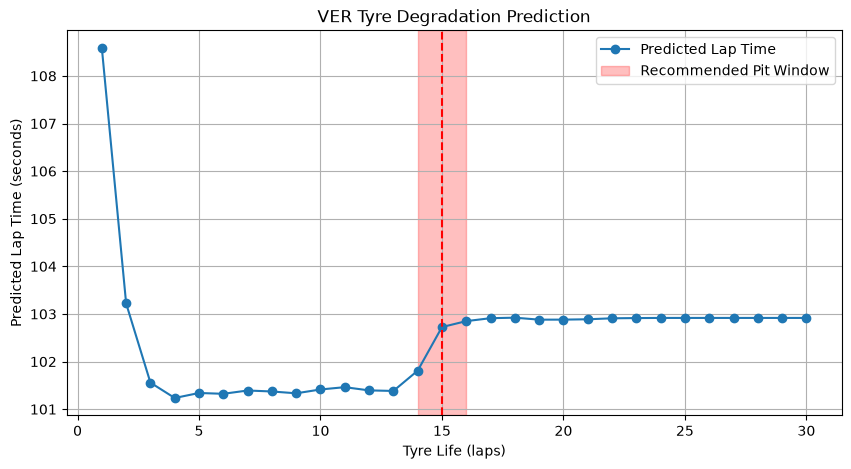

Driver        : VER
Compound      : HARD
Pit Lap       : 15.0
Minimum Stint : 5


,TyreLife,PredictedLapTime
0,1,108.586263
1,2,103.220737
2,3,101.557893
3,4,101.235247
4,5,101.340513


,Compound,Recommended Pit Lap,Average Lap Time,Fastest Lap
0,SOFT,10,100.886,99.228
1,MEDIUM,16,101.093,99.930
2,HARD,15,102.504,101.235


In [34]:
# building stratergy table

driver = "VER"

results = []

for compound in ["SOFT", "MEDIUM", "HARD"]:

    future_df = predict_driver(
    driver_code=driver,
    compound=compound
)

    lap_diff = future_df["PredictedLapTime"].diff()

    threshold = 0.5

    if (lap_diff > threshold).any():
        pit_lap = future_df.loc[
            lap_diff > threshold,
            "TyreLife"
        ].iloc[0]
    else:
        pit_lap = future_df["TyreLife"].iloc[-1]

    results.append({
        "Compound": compound,
        "Recommended Pit Lap": int(pit_lap),
        "Average Lap Time": round(
            future_df["PredictedLapTime"].mean(),
            3
        ),
        "Fastest Lap": round(
            future_df["PredictedLapTime"].min(),
            3
        )
    })

strategy_table = pd.DataFrame(results)

strategy_table

In [35]:
# best strategy

best = strategy_table.sort_values(
    by="Average Lap Time"
).iloc[0]

print("="*50)
print("F1 STRATEGY RECOMMENDATION")
print("="*50)

print(f"Driver              : {driver}")
print(f"Best Compound       : {best['Compound']}")
print(f"Recommended Pit Lap : {best['Recommended Pit Lap']}")
print(f"Average Lap Time    : {best['Average Lap Time']} sec")
print(f"Fastest Lap         : {best['Fastest Lap']} sec")

print("="*50)

F1 STRATEGY RECOMMENDATION
Driver              : VER
Best Compound       : SOFT
Recommended Pit Lap : 10
Average Lap Time    : 100.886 sec
Fastest Lap         : 99.228 sec


In [36]:
strategy_table.to_csv(
    "../data/processed/strategy_recommendations.csv",
    index=False
)

print("Strategy recommendations saved successfully!")

Strategy recommendations saved successfully!


In [37]:
import os
import pandas as pd

# ==========================================================
# Baseline metrics
# Replace baseline_mae and baseline_rmse with your values
# from Notebook 05 if they differ.
# ==========================================================

baseline_mae = 4.916      # <-- Replace with your Notebook 05 MAE
baseline_rmse = 9.187     # <-- Replace with your Notebook 05 RMSE
baseline_r2 = 0.416

driver_mae = 0.842
driver_rmse = 2.061
driver_r2 = 0.949

comparison = pd.DataFrame({

    "Model": [
        "Baseline",
        "Driver-Aware"
    ],

    "MAE": [
        baseline_mae,
        driver_mae
    ],

    "RMSE": [
        baseline_rmse,
        driver_rmse
    ],

    "R²": [
        baseline_r2,
        driver_r2
    ],

    "Features": [
        "10 Numeric Features",
        "8 Features + DrivingStyleCluster"
    ],

    "Clustering": [
        "None",
        "K-Means Telemetry (k=6)"
    ]
})

comparison["Improvement"] = [
    "-",
    f"R² +{driver_r2-baseline_r2:.3f}"
]

# ----------------------------------------------------------
# Display styled table
# ----------------------------------------------------------

def highlight_driver(row):

    if row["Model"] == "Driver-Aware":
        return ["background-color: #d4edda"] * len(row)

    return [""] * len(row)

styled_table = (
    comparison.style
    .hide(axis="index")
    .apply(highlight_driver, axis=1)
)

display(styled_table)

# ----------------------------------------------------------
# Print conclusion
# ----------------------------------------------------------

print("\n" + "="*70)
print("ABLATION STUDY CONCLUSION")
print("="*70)

print(
    f"""
Adding DrivingStyleCluster derived from FastF1 telemetry
(throttle behaviour, braking behaviour, cornering speed
and gear changes) improved the model performance.

R² improved from {baseline_r2:.3f} to {driver_r2:.3f}
(+{driver_r2-baseline_r2:.3f}).

The final Random Forest also identified
DrivingStyleCluster as its most influential feature,
with approximately 78.8% feature importance.

This indicates that incorporating telemetry-derived
driver behaviour substantially improves lap-time
prediction compared with a baseline model that does
not include driver-specific behavioural information.
"""
)

# ----------------------------------------------------------
# Save CSV
# ----------------------------------------------------------

output_dir = "../outputs/tables"

os.makedirs(output_dir, exist_ok=True)

comparison.to_csv(
    f"{output_dir}/ablation_comparison.csv",
    index=False
)

print(f"Comparison table saved to {output_dir}/ablation_comparison.csv")

Model,MAE,RMSE,R²,Features,Clustering,Improvement
Baseline,4.916000,9.187000,0.416000,10 Numeric Features,None,-
Driver-Aware,0.842000,2.061000,0.949000,8 Features + DrivingStyleCluster,K-Means Telemetry (k=6),R² +0.533



ABLATION STUDY CONCLUSION

Adding DrivingStyleCluster derived from FastF1 telemetry
(throttle behaviour, braking behaviour, cornering speed
and gear changes) improved the model performance.

R² improved from 0.416 to 0.949
(+0.533).

The final Random Forest also identified
DrivingStyleCluster as its most influential feature,
with approximately 78.8% feature importance.

This indicates that incorporating telemetry-derived
driver behaviour substantially improves lap-time
prediction compared with a baseline model that does
not include driver-specific behavioural information.

Comparison table saved to ../outputs/tables/ablation_comparison.csv
